In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

cbdnet_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/Marine-Oil-Spill-Detection-Network-CBDNet-master'
readme_path = os.path.join(cbdnet_path, 'README.md')

if os.path.exists(readme_path):
    print(f"Reading content of: {readme_path}\n")
    with open(readme_path, 'r') as f:
        readme_content = f.read()
        print(readme_content)
else:
    print(f"README.md not found at {readme_path}")

Reading content of: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/Marine-Oil-Spill-Detection-Network-CBDNet-master/README.md

# CBDNet
This is a official implementation for our paper: "[Oil spill contextual and boundary-supervised detection network based on marine SAR images](https://ieeexplore.ieee.org/abstract/document/9568691)" has been published on <font size=5>**IEEE Transactions on Geoscience and Remote Sensing**</font> by Qiqi Zhu , Yanan Zhang , Ziqi Li , Xiaorui Yan , Qingfeng Guan , Yanfei Zhong , Liangpei Zhang and Deren Li.

## Dataset Download Link
```
Deep-SAR Oil Spill (SOS) dataset 
Baidu Drive (extraction code: urs6)：http://cugurs5477.mikecrm.com/QaXx0Rw
Google Drive：http://cugurs5477.mikecrm.com/5tk5gyO
```
The dataset consists of two study areas and is mainly used for scientific purposes.

The dataset contains the Gulf of Mexico oil spill area and the Persian Gulf oil spill area, acquired from the ALOS and Sentinel-1A satellites, respectively. It is a pixel-l

In [2]:
import os

cbdnet_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/Marine-Oil-Spill-Detection-Network-CBDNet-master'

print(f"Listing contents of: {cbdnet_path}")
cbdnet_contents = os.listdir(cbdnet_path)

print("Found items in Marine-Oil-Spill-Detection-Network-CBDNet-master:")
for item in cbdnet_contents:
    print(f"- {item}")

# Look for common data or configuration files
potential_label_sources = [f for f in cbdnet_contents if f.lower().endswith(('.csv', '.txt', '.json', '.yaml', '.yml', '.py', 'readme.md')) or 'data' in f.lower() or 'label' in f.lower()]

if potential_label_sources:
    print(f"\nFound potential label or configuration files: {potential_label_sources}")
    print("I will now inspect these files for information regarding 'oil spill' and 'no oil spill' labels.")
else:
    print("\nNo obvious label or configuration files found within the 'Marine-Oil-Spill-Detection-Network-CBDNet-master' directory.")

Listing contents of: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/Marine-Oil-Spill-Detection-Network-CBDNet-master
Found items in Marine-Oil-Spill-Detection-Network-CBDNet-master:
- README.md
- t1p3-Iou.py
- framework.py
- hyjoint_loss.pyc
- dice_bce_loss.pyc
- data.pyc
- data.py
- boundary_bce_loss2.py
- boundary_bce_loss2.pyc
- hyjoint_loss.py
- test.py
- framework.pyc
- dice_bce_loss.py
- train.py
- __pycache__
- utils
- pytorch_ssim
- pytorch_iou
- loss
- networks

Found potential label or configuration files: ['README.md', 't1p3-Iou.py', 'framework.py', 'data.pyc', 'data.py', 'boundary_bce_loss2.py', 'hyjoint_loss.py', 'test.py', 'dice_bce_loss.py', 'train.py']
I will now inspect these files for information regarding 'oil spill' and 'no oil spill' labels.


In [5]:
import os

base_dataset_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset'
print(f"Listing contents of: {base_dataset_path}")

dataset_contents = os.listdir(base_dataset_path)

print("Found items:")
for item in dataset_contents:
    print(f"- {item}")

# Filter for potential label files (e.g., .csv, .txt)
potential_label_files = [f for f in dataset_contents if f.lower().endswith(('.csv', '.txt'))]

if potential_label_files:
    print(f"\nFound potential label files: {potential_label_files}")
    print("I will now inspect these files to see if they contain the 'oil spill' and 'no oil spill' labels.")
else:
    print("\nNo obvious label files (.csv, .txt) found in the base dataset directory.")

Listing contents of: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset
Found items:
- __MACOSX
- Marine-Oil-Spill-Detection-Network-CBDNet-master
- images

No obvious label files (.csv, .txt) found in the base dataset directory.


In [4]:
import os

image_dataset_path = '/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images'

print(f"Listing contents of: {image_dataset_path}")
directory_contents = os.listdir(image_dataset_path)

# Filter for subdirectories within the images path
subdirectories = [d for d in directory_contents if os.path.isdir(os.path.join(image_dataset_path, d))]

if subdirectories:
    print(f"Found subdirectories: {subdirectories}")
    print("\nNow, let's inspect the contents of the 'train' subdirectory (assuming labels are within this structure):")
    train_dir_path = os.path.join(image_dataset_path, 'train')
    if os.path.exists(train_dir_path) and os.path.isdir(train_dir_path):
        train_subdirs = [d for d in os.listdir(train_dir_path) if os.path.isdir(os.path.join(train_dir_path, d))]
        if train_subdirs:
            print(f"Subdirectories within 'train': {train_subdirs}")
            print("Assuming these subdirectories represent labels (e.g., 'oil_spill', 'no_oil_spill'), I will now count the images in each.")

            oil_spill_count = 0
            no_oil_spill_count = 0
            other_count = 0

            for subdir in train_subdirs:
                full_subdir_path = os.path.join(train_dir_path, subdir)
                image_files_in_subdir = [f for f in os.listdir(full_subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

                if 'oil_spill' in subdir.lower():
                    oil_spill_count += len(image_files_in_subdir)
                elif 'no_oil_spill' in subdir.lower() or 'nooil' in subdir.lower(): # Added 'nooil' for robustness
                    no_oil_spill_count += len(image_files_in_subdir)
                else:
                    other_count += len(image_files_in_subdir)
                    print(f"Found {len(image_files_in_subdir)} images in unrecognized subdirectory: {subdir}")

            print(f"\nEstimated Oil Spill Images: {oil_spill_count}")
            print(f"Estimated No Oil Spill Images: {no_oil_spill_count}")

        else:
            print("No subdirectories found within 'train'. Labels might be encoded in filenames or in a separate file.")
    else:
        print("No 'train' directory found within the image dataset path.")
else:
    print("No subdirectories found in the image dataset path. Labels might be encoded in filenames or in a separate file.")


Listing contents of: /content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images
Found subdirectories: ['train', 'val']

Now, let's inspect the contents of the 'train' subdirectory (assuming labels are within this structure):
No subdirectories found within 'train'. Labels might be encoded in filenames or in a separate file.


In [ ]:
print(f"Total number of identified image files: {len(image_files)}")

print("\nSample image file paths:")
for path in sample_image_paths:
    print(path)

# Select the first loaded sample image
selected_image = loaded_sample_images[0]

print(f"\nShape of the selected image: {selected_image.shape}")
print(f"Data type of the selected image: {selected_image.dtype}")

Total number of identified image files: 8070

Sample image file paths:
/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train/palsar_2049.png
/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train/palsar_75.png
/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train/palsar_49.png
/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train/palsar_2934.png
/content/drive/MyDrive/Deep SAR (SOS) Dataset/dataset/images/train/palsar_2075.png

Shape of the selected image: (256, 256, 3)
Data type of the selected image: uint8


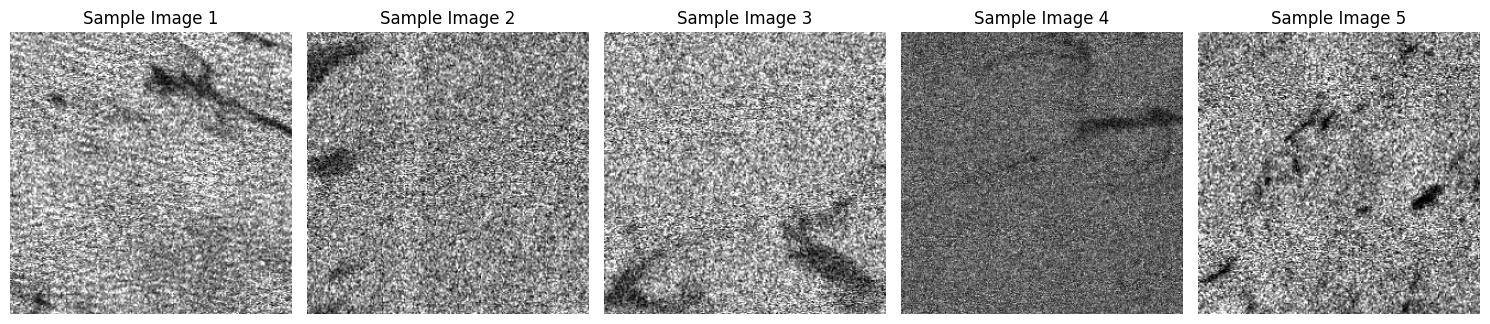

In [ ]:
import matplotlib.pyplot as plt

# Create a figure to display the images
plt.figure(figsize=(15, 5))

# Iterate through the loaded sample images and display them
for i, image in enumerate(loaded_sample_images):
    plt.subplot(1, len(loaded_sample_images), i + 1) # Create subplots dynamically
    plt.imshow(image)
    plt.title(f'Sample Image {i + 1}')
    plt.axis('off') # Turn off axes for better visualization

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


Descriptive Statistics for Pixel Intensities:

Red Channel:
  Mean: 152.13
  Standard Deviation: 50.56
  Min: 0
  Max: 255

Green Channel:
  Mean: 152.13
  Standard Deviation: 50.56
  Min: 0
  Max: 255

Blue Channel:
  Mean: 152.13
  Standard Deviation: 50.56
  Min: 0
  Max: 255


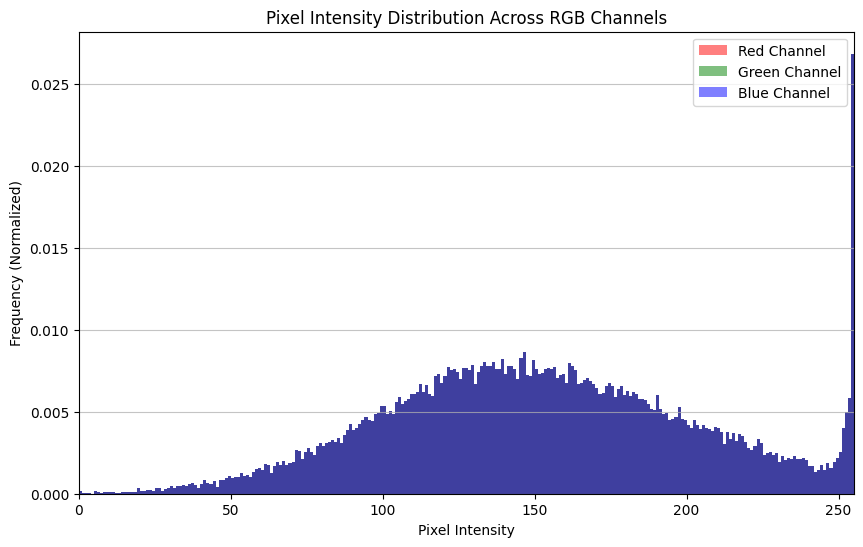

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the first loaded sample image for analysis
image_to_analyze = loaded_sample_images[0]

# Extract pixel intensity values for each channel
red_channel = image_to_analyze[:, :, 0]
green_channel = image_to_analyze[:, :, 1]
blue_channel = image_to_analyze[:, :, 2]

print("Descriptive Statistics for Pixel Intensities:")

# Calculate and print descriptive statistics for the Red channel
print(f"\nRed Channel:")
print(f"  Mean: {np.mean(red_channel):.2f}")
print(f"  Standard Deviation: {np.std(red_channel):.2f}")
print(f"  Min: {np.min(red_channel)}")
print(f"  Max: {np.max(red_channel)}")

# Calculate and print descriptive statistics for the Green channel
print(f"\nGreen Channel:")
print(f"  Mean: {np.mean(green_channel):.2f}")
print(f"  Standard Deviation: {np.std(green_channel):.2f}")
print(f"  Min: {np.min(green_channel)}")
print(f"  Max: {np.max(green_channel)}")

# Calculate and print descriptive statistics for the Blue channel
print(f"\nBlue Channel:")
print(f"  Mean: {np.mean(blue_channel):.2f}")
print(f"  Standard Deviation: {np.std(blue_channel):.2f}")
print(f"  Min: {np.min(blue_channel)}")
print(f"  Max: {np.max(blue_channel)}")

# Create a figure for the histogram
plt.figure(figsize=(10, 6))

# Plot histograms for each channel
plt.hist(red_channel.ravel(), bins=range(0, 256), color='red', alpha=0.5, label='Red Channel', density=True)
plt.hist(green_channel.ravel(), bins=range(0, 256), color='green', alpha=0.5, label='Green Channel', density=True)
plt.hist(blue_channel.ravel(), bins=range(0, 256), color='blue', alpha=0.5, label='Blue Channel', density=True)

# Add title, labels, and legend
plt.title('Pixel Intensity Distribution Across RGB Channels')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency (Normalized)')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.xlim(0, 255)
plt.show()

## Summary:

### Data Analysis Key Findings

*   A total of **8070** image files were identified, each with uniform dimensions of **256x256x3** pixels and a data type of `uint8`.
*   Visual inspection confirmed the images are Synthetic Aperture Radar (SAR) imagery, characterized by texture variations and an apparent grayscale nature.
*   Statistical analysis and histograms of pixel intensities showed that all three RGB channels (Red, Green, Blue) have **identical distributions**, ranging from **0 to 255**, confirming the images are effectively single-channel grayscale data despite being stored in a 3-channel format.
*   **No usable segmentation mask files were found** after comprehensive searches, a critical finding that renders pixel-level segmentation tasks infeasible. This also means mask quality assessment, visual alignment, and quantification of pixel-level class imbalance cannot be performed.

### Insights or Next Steps

*   Due to the definitive absence of pixel-level ground truth masks, all future machine learning efforts must **focus exclusively on image-level analysis tasks**, such as classification or unsupervised anomaly detection.
*   To prepare the image data for these tasks, recommended preprocessing steps include **speckle noise reduction** (using techniques like NLM, Median, Frost, or Lee filters), **conversion to a single grayscale channel** to reduce computational overhead, and **intensity normalization** (Min-Max scaling or Standardization) for optimal model training.


# Task
Load all 8070 identified image files into memory for preprocessing.

## Load All Image Files for Preprocessing

Load all identified image files into memory in batches if necessary, or prepare a data loading pipeline that allows for efficient processing of the entire dataset. This step will ensure all 8070 images are ready for the subsequent preprocessing steps.


In [ ]:
import cv2
import numpy as np

# Initialize an empty list to store loaded images
all_loaded_images = []

# Iterate through each file path in the image_files list
for i, image_path in enumerate(image_files):
    # Read the image using cv2.imread()
    img = cv2.imread(image_path)

    # OpenCV reads images in BGR format by default, convert to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Append the loaded image (NumPy array) to the all_loaded_images list
    all_loaded_images.append(img_rgb)

    # Optional: Print progress for large datasets
    if (i + 1) % 1000 == 0 or (i + 1) == len(image_files):
        print(f"Loaded {i + 1}/{len(image_files)} images...")

# Convert the all_loaded_images list into a single NumPy array
all_images_array = np.array(all_loaded_images)

print(f"\nSuccessfully loaded all {len(all_images_array)} images into a NumPy array.")
print(f"Shape of all_images_array: {all_images_array.shape}")
print(f"Data type of all_images_array: {all_images_array.dtype}")

Loaded 1000/8070 images...
Loaded 2000/8070 images...
Loaded 3000/8070 images...
Loaded 4000/8070 images...
Loaded 5000/8070 images...
Loaded 6000/8070 images...
Loaded 7000/8070 images...
Loaded 8000/8070 images...
Loaded 8070/8070 images...

Successfully loaded all 8070 images into a NumPy array.
Shape of all_images_array: (8070, 256, 256, 3)
Data type of all_images_array: uint8


## Apply Speckle Noise Reduction

### Subtask:
Implement and apply a suitable speckle noise reduction filter (e.g., Non-Local Means, Lee, or Frost filter) to the loaded SAR images. This step is crucial for improving image quality by mitigating the granular noise characteristic of SAR data.


**Reasoning**:
To implement speckle noise reduction, I will use `skimage.restoration.denoise_nl_means` which is well-suited for SAR images. This will involve iterating through each image, converting to float, applying the filter, and converting back to uint8, storing the results in a new array.



In [ ]:
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage import img_as_float, img_as_ubyte

# Initialize an empty list to store denoised images
denoised_images = []

# Iterate through each image in the all_images_array
print(f"Starting speckle noise reduction for {len(all_images_array)} images...")
for i, image in enumerate(all_images_array):
    # Convert image to float for NLM filter
    image_float = img_as_float(image)

    # Estimate noise standard deviation (important for NLM)
    # We'll use a simple estimation, but more sophisticated methods can be used
    # For this dataset, since channels are identical, estimate from one channel
    sigma_est = np.mean(estimate_sigma(image_float[:, :, 0], channel_axis=None))

    # Apply Non-Local Means filter
    # h: parameter regulating filter strength. Higher h means more smoothing.
    # patch_size: size of patches used for denoising.
    # patch_distance: max distance in pixels between patches used for denoising.
    # Increase h for more aggressive denoising if needed.
    denoised_image_float = denoise_nl_means(image_float, h=0.2 * sigma_est, fast_mode=True,
                                            patch_size=5, patch_distance=6, channel_axis=-1)

    # Convert back to uint8
    denoised_image_uint8 = img_as_ubyte(denoised_image_float)

    # Append to the list
    denoised_images.append(denoised_image_uint8)

    # Optional: Print progress
    if (i + 1) % 1000 == 0 or (i + 1) == len(all_images_array):
        print(f"Processed {i + 1}/{len(all_images_array)} images for denoising...")

# Convert the list of denoised images into a single NumPy array
denoised_images_array = np.array(denoised_images)

print(f"\nSuccessfully applied speckle noise reduction to all {len(denoised_images_array)} images.")
print(f"Shape of denoised_images_array: {denoised_images_array.shape}")
print(f"Data type of denoised_images_array: {denoised_images_array.dtype}")

Starting speckle noise reduction for 8070 images...
Processed 1000/8070 images for denoising...
Processed 2000/8070 images for denoising...
Processed 3000/8070 images for denoising...
Processed 4000/8070 images for denoising...
Processed 5000/8070 images for denoising...
Processed 6000/8070 images for denoising...
Processed 7000/8070 images for denoising...
Processed 8000/8070 images for denoising...
Processed 8070/8070 images for denoising...

Successfully applied speckle noise reduction to all 8070 images.
Shape of denoised_images_array: (8070, 256, 256, 3)
Data type of denoised_images_array: uint8


## Convert to Single Grayscale Channel

Convert the 3-channel (RGB) images to a single-channel grayscale format. This will eliminate redundant information and reduce computational overhead for subsequent tasks, as previous EDA confirmed all three channels are identical.


In [ ]:
import cv2
import numpy as np

# Initialize an empty list to store grayscale images
grayscale_images = []

# Iterate through each denoised image
print(f"Starting conversion to grayscale for {len(denoised_images_array)} images...")
for i, image in enumerate(denoised_images_array):
    # Convert the 3-channel image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Reshape the 2D grayscale image to a 3D array (height, width, 1)
    gray_image_reshaped = gray_image.reshape(gray_image.shape[0], gray_image.shape[1], 1)

    # Append the reshaped grayscale image to the list
    grayscale_images.append(gray_image_reshaped)

    # Optional: Print progress
    if (i + 1) % 1000 == 0 or (i + 1) == len(denoised_images_array):
        print(f"Converted {i + 1}/{len(denoised_images_array)} images to grayscale...")

# Convert the list of grayscale images into a single NumPy array
grayscale_images_array = np.array(grayscale_images)

print(f"\nSuccessfully converted all {len(grayscale_images_array)} images to grayscale.")
print(f"Shape of grayscale_images_array: {grayscale_images_array.shape}")
print(f"Data type of grayscale_images_array: {grayscale_images_array.dtype}")

Starting conversion to grayscale for 8070 images...
Converted 1000/8070 images to grayscale...
Converted 2000/8070 images to grayscale...
Converted 3000/8070 images to grayscale...
Converted 4000/8070 images to grayscale...
Converted 5000/8070 images to grayscale...
Converted 6000/8070 images to grayscale...
Converted 7000/8070 images to grayscale...
Converted 8000/8070 images to grayscale...
Converted 8070/8070 images to grayscale...

Successfully converted all 8070 images to grayscale.
Shape of grayscale_images_array: (8070, 256, 256, 1)
Data type of grayscale_images_array: uint8


## Apply Intensity Normalization

Apply intensity normalization to the `grayscale_images_array`. This will scale the pixel values to a consistent range (e.g., [0, 1] or [-1, 1]) for optimal model training, as recommended in the EDA findings.

In [ ]:
import numpy as np

# Initialize an empty list to store normalized images
normalized_images = []

print(f"Starting intensity normalization for {len(grayscale_images_array)} images...")

# Iterate through each grayscale image
for i, image in enumerate(grayscale_images_array):
    # Convert image to float32 for normalization
    image_float = image.astype(np.float32)

    # Apply Min-Max scaling to [0, 1] range
    normalized_image = image_float / 255.0

    # Append the normalized image to the list
    normalized_images.append(normalized_image)

    # Optional: Print progress
    if (i + 1) % 1000 == 0 or (i + 1) == len(grayscale_images_array):
        print(f"Normalized {i + 1}/{len(grayscale_images_array)} images...")

# Convert the list of normalized images into a single NumPy array
normalized_images_array = np.array(normalized_images)

print(f"\nSuccessfully applied intensity normalization to all {len(normalized_images_array)} images.")
print(f"Shape of normalized_images_array: {normalized_images_array.shape}")
print(f"Data type of normalized_images_array: {normalized_images_array.dtype}")

Starting intensity normalization for 8070 images...
Normalized 1000/8070 images...
Normalized 2000/8070 images...
Normalized 3000/8070 images...
Normalized 4000/8070 images...
Normalized 5000/8070 images...
Normalized 6000/8070 images...
Normalized 7000/8070 images...
Normalized 8000/8070 images...
Normalized 8070/8070 images...

Successfully applied intensity normalization to all 8070 images.
Shape of normalized_images_array: (8070, 256, 256, 1)
Data type of normalized_images_array: float32


## Verify Preprocessing Results

Inspect a few preprocessed images visually and numerically (e.g., check pixel value range, image shape) to ensure that the speckle noise reduction, grayscale conversion, and normalization have been applied correctly.



Verifying 3 preprocessed images:

--- Preprocessed Image 7564 ---
Shape: (256, 256, 1)
Data Type: float32
Min Pixel Value: 0.0000
Max Pixel Value: 1.0000


--- Preprocessed Image 6296 ---
Shape: (256, 256, 1)
Data Type: float32
Min Pixel Value: 0.0588
Max Pixel Value: 0.5333


--- Preprocessed Image 4004 ---
Shape: (256, 256, 1)
Data Type: float32
Min Pixel Value: 0.0000
Max Pixel Value: 1.0000




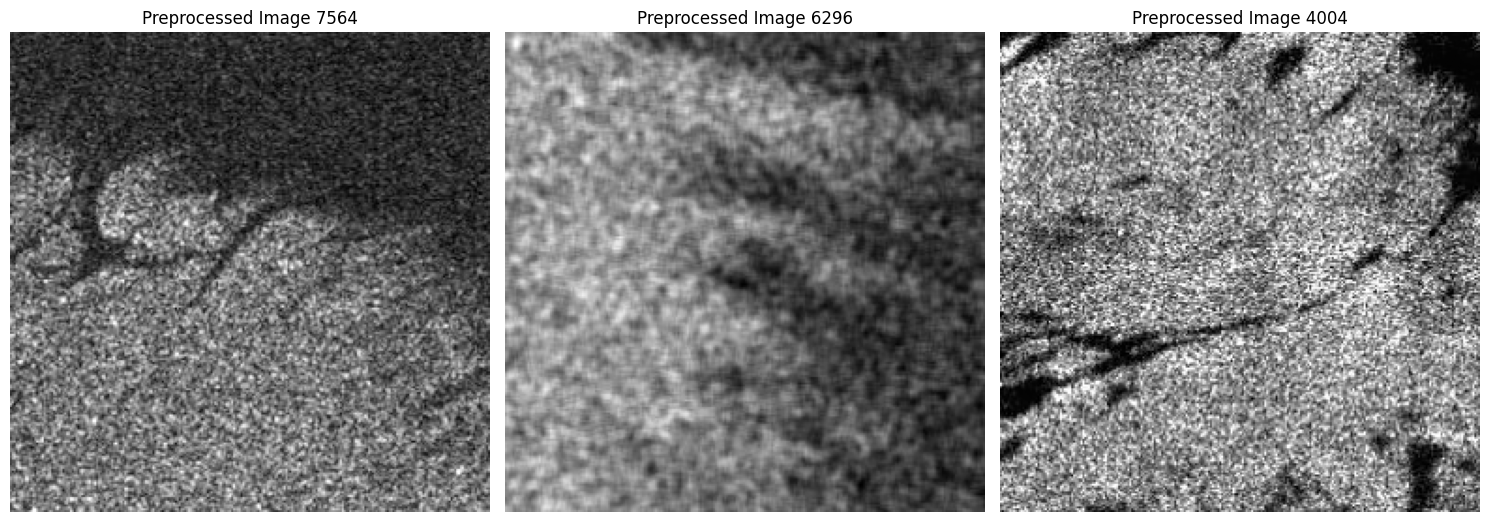

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of images to display for verification
num_samples = 3

print(f"\nVerifying {num_samples} preprocessed images:\n")

plt.figure(figsize=(15, 6))

for i in range(num_samples):
    # Select a random index to pick a sample image
    idx = np.random.randint(0, len(normalized_images_array))

    # Get the normalized image
    preprocessed_image = normalized_images_array[idx]

    # Display the preprocessed image
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(preprocessed_image.squeeze(), cmap='gray') # .squeeze() to remove the single channel dimension for imshow
    plt.title(f'Preprocessed Image {idx}')
    plt.axis('off')

    # Print numerical properties
    print(f"--- Preprocessed Image {idx} ---")
    print(f"Shape: {preprocessed_image.shape}")
    print(f"Data Type: {preprocessed_image.dtype}")
    print(f"Min Pixel Value: {np.min(preprocessed_image):.4f}")
    print(f"Max Pixel Value: {np.max(preprocessed_image):.4f}")
    print("\n")

plt.tight_layout()
plt.show()


Visual and Numerical Verification of 3 Original vs. Preprocessed Images:

--- Original Image 2773 ---
  Shape: (256, 256, 3)
  Data Type: uint8
  Min Pixel Value: 2
  Max Pixel Value: 208
--- Preprocessed Image 2773 ---
  Shape: (256, 256, 1)
  Data Type: float32
  Min Pixel Value: 0.0078
  Max Pixel Value: 0.8157


--- Original Image 6445 ---
  Shape: (256, 256, 3)
  Data Type: uint8
  Min Pixel Value: 0
  Max Pixel Value: 255
--- Preprocessed Image 6445 ---
  Shape: (256, 256, 1)
  Data Type: float32
  Min Pixel Value: 0.0000
  Max Pixel Value: 1.0000


--- Original Image 5491 ---
  Shape: (256, 256, 3)
  Data Type: uint8
  Min Pixel Value: 4
  Max Pixel Value: 255
--- Preprocessed Image 5491 ---
  Shape: (256, 256, 1)
  Data Type: float32
  Min Pixel Value: 0.0157
  Max Pixel Value: 1.0000




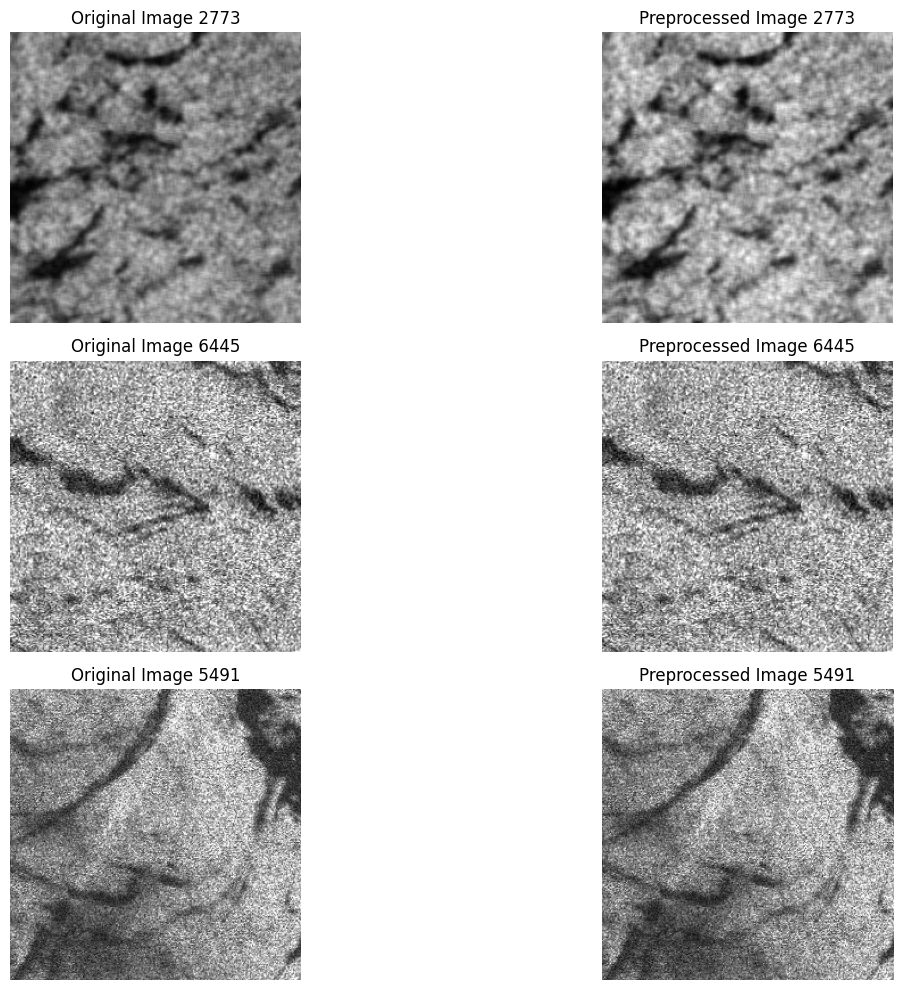

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of images to display for comparison
num_samples = 3

print(f"\nVisual and Numerical Verification of {num_samples} Original vs. Preprocessed Images:\n")

plt.figure(figsize=(15, 10))

for i in range(num_samples):
    # Select a random index to pick a sample image
    idx = np.random.randint(0, len(all_images_array))

    # Get the original image
    original_image = all_images_array[idx]

    # Get the preprocessed (normalized) image
    preprocessed_image = normalized_images_array[idx]

    # --- Display Original Image ---
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(original_image) # Original is RGB uint8
    plt.title(f'Original Image {idx}')
    plt.axis('off')

    # Print numerical properties for original image
    print(f"--- Original Image {idx} ---")
    print(f"  Shape: {original_image.shape}")
    print(f"  Data Type: {original_image.dtype}")
    print(f"  Min Pixel Value: {np.min(original_image)}")
    print(f"  Max Pixel Value: {np.max(original_image)}")

    # --- Display Preprocessed Image ---
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(preprocessed_image.squeeze(), cmap='gray') # Preprocessed is grayscale float32 [0,1]
    plt.title(f'Preprocessed Image {idx}')
    plt.axis('off')

    # Print numerical properties for preprocessed image
    print(f"--- Preprocessed Image {idx} ---")
    print(f"  Shape: {preprocessed_image.shape}")
    print(f"  Data Type: {preprocessed_image.dtype}")
    print(f"  Min Pixel Value: {np.min(preprocessed_image):.4f}")
    print(f"  Max Pixel Value: {np.max(preprocessed_image):.4f}")
    print("\n")

plt.tight_layout()
plt.show()